In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# Unzip the dataset if not already unzipped
zip_file_path = "/content/northstar_dataset.zip"
extract_path = "northstar_dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print(f"'{zip_file_path}' unzipped to '{extract_path}/'")
else:
    print(f"'{extract_path}/' directory already exists, skipping unzip.")

# Load the NorthStar CSV files
orders = pd.read_csv(os.path.join(extract_path, "orders.csv"))
deliveries = pd.read_csv(os.path.join(extract_path, "deliveries.csv"))
customers = pd.read_csv(os.path.join(extract_path, "customers.csv"))
drivers = pd.read_csv(os.path.join(extract_path, "drivers.csv"))
hubs = pd.read_csv(os.path.join(extract_path, "hubs.csv"))
vehicles = pd.read_csv(os.path.join(extract_path, "vehicles.csv"))
complaints = pd.read_csv(os.path.join(extract_path, "complaints.csv"))
incidents = pd.read_csv(os.path.join(extract_path, "incidents.csv"))
app_events = pd.read_csv(os.path.join(extract_path, "app_events.csv"))

# Check if the files loaded
print("Data loaded")
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Customers:", customers.shape)
print("Complaints:", complaints.shape)


'/content/northstar_dataset.zip' unzipped to 'northstar_dataset/'
Data loaded
Orders: (1250, 11)
Deliveries: (950, 13)
Customers: (650, 9)
Complaints: (320, 10)


In [2]:
# Basic data checking

print("Orders information")
orders.info()

print("\nFirst few rows from orders")
print(orders.head())

print("\nFirst few rows from deliveries")
print(deliveries.head())

print("\nDelivery summary")
print(deliveries.describe())


Orders information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1250 non-null   object 
 1   customer_id            1250 non-null   object 
 2   service_type           1250 non-null   object 
 3   order_created_at       1250 non-null   object 
 4   promised_window_hours  1250 non-null   int64  
 5   pickup_zone            1250 non-null   object 
 6   dropoff_zone           1250 non-null   object 
 7   priority_level         1250 non-null   object 
 8   order_value            1250 non-null   float64
 9   booking_channel        1225 non-null   object 
 10  special_handling_flag  1250 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 107.6+ KB

First few rows from orders
  order_id customer_id service_type     order_created_at  \
0   O00001       C0292    Passenger  2024-08-2

In [3]:
# Check missing values in main tables

tables = {
    "orders": orders,
    "deliveries": deliveries,
    "customers": customers,
    "complaints": complaints
}

for table_name, data in tables.items():
    print("\n", table_name)
    print(data.isnull().sum())

# Check delivery status count
print("\nDelivery status count")
print(deliveries["delivery_status"].value_counts())

# Check delivery status percentage
print("\nDelivery status percentage")
print(round(deliveries["delivery_status"].value_counts(normalize=True) * 100, 2))



 orders
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

 deliveries
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

 customers
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
ap

In [4]:
# Merge orders and deliveries

merged = pd.merge(orders, deliveries, on="order_id", how="inner")

print("Merged data shape:", merged.shape)

# Check duplicate rows
print("Duplicate rows:", merged.duplicated().sum())

# Change date columns into datetime format
merged["dispatch_time"] = pd.to_datetime(merged["dispatch_time"], errors="coerce")
merged["delivery_completed_at"] = pd.to_datetime(merged["delivery_completed_at"], errors="coerce")

# Create delivery time in hours
merged["delivery_hours"] = (
    merged["delivery_completed_at"] - merged["dispatch_time"]
).dt.total_seconds() / 3600

merged["delivery_hours"] = merged["delivery_hours"].round(2)

# Check result
print("Data types after changes")
print(merged.dtypes)

print("Valid delivery hours:", merged["delivery_hours"].notna().sum())


Merged data shape: (950, 23)
Duplicate rows: 0
Data types after changes
order_id                                 object
customer_id                              object
service_type                             object
order_created_at                         object
promised_window_hours                     int64
pickup_zone                              object
dropoff_zone                             object
priority_level                           object
order_value                             float64
booking_channel                          object
special_handling_flag                     int64
delivery_id                              object
driver_id                                object
vehicle_id                               object
hub_id                                   object
dispatch_time                    datetime64[ns]
delivery_completed_at            datetime64[ns]
delivery_status                          object
route_distance_km                       float64
manual_route_ove

In [5]:
# Zone level analysis

zone_analysis = merged.groupby("pickup_zone").agg(
    total_deliveries = ("delivery_id", "count"),
    failed_deliveries = ("delivery_status", lambda x: (x == "failed").sum()),
    delayed_deliveries = ("delivery_status", lambda x: (x == "delayed").sum()),
    average_rating = ("customer_rating_post_delivery", "mean"),
    average_cost = ("fuel_or_charge_cost", "mean"), # Added missing comma here
    total_order_value = ("order_value", "sum"),
    total_delivery_cost = ("fuel_or_charge_cost", "sum") # Fixed typo here
).reset_index()

# calculate failure percentage

zone_analysis["failure_percentage"] = (
    zone_analysis["failed_deliveries"] / zone_analysis["total_deliveries"] * 100
    ).round(2)

# calculate simple profit value

zone_analysis["profit"] = (
    zone_analysis["total_order_value"] - zone_analysis["total_delivery_cost"]
    ).round(2
).round(2)

zone_analysis = zone_analysis.sort_values("failure_percentage", ascending=False)

print("zone_performance")
print(zone_analysis[[
    "pickup_zone",
    "failed_deliveries", # Added missing comma here
    "delayed_deliveries",
    "total_deliveries", # Added missing comma here
    "average_rating",
    "profit"

]])

zone_performance
   pickup_zone  failed_deliveries  delayed_deliveries  total_deliveries  \
0      AIRPORT                  0                   0                46   
1      Airport                  0                   0                67   
2      CENTRAL                  0                   0                55   
3      Central                  0                   0                55   
4          Ctr                  0                   0                64   
5         EAST                  0                   0                78   
6         East                  0                   0                78   
7        NORTH                  0                   0                46   
8        North                  0                   0                37   
9    RiverSide                  0                   0                66   
10   Riverside                  0                   0                53   
11       SOUTH                  0                   0                56   
12      

In [6]:
# Service type analysis

service_analysis = merged.groupby("service_type").agg(
    total_orders=("order_id", "count"),
    total_order_value=("order_value", "sum"),
    average_order_value=("order_value", "mean"),
    total_delivery_cost=("fuel_or_charge_cost", "sum"),
    failed_deliveries=("delivery_status", lambda x: (x == "Failed").sum()),
    average_rating=("customer_rating_post_delivery", "mean")
).reset_index()

# Calculate simple profit
service_analysis["profit"] = (
    service_analysis["total_order_value"] - service_analysis["total_delivery_cost"]
).round(2)

# Calculate failed delivery percentage
service_analysis["failed_percentage"] = (
    service_analysis["failed_deliveries"] / service_analysis["total_orders"] * 100
).round(2)

service_analysis = service_analysis.sort_values("profit", ascending=True)

print("Service type analysis")
print(service_analysis[[
    "service_type",
    "total_orders",
    "total_order_value",
    "total_delivery_cost",
    "profit",
    "failed_deliveries",
    "failed_percentage",
    "average_rating"
]])


Service type analysis
  service_type  total_orders  total_order_value  total_delivery_cost  \
1      Medical           108            9344.88              1379.48   
0     Business           126           12279.23              1655.91   
4       Retail           224           19444.86              2906.27   
2       Parcel           230           20735.44              3009.01   
3    Passenger           262           25463.36              3248.56   

     profit  failed_deliveries  failed_percentage  average_rating  
1   7965.40                 16              14.81        3.837685  
0  10623.32                 25              19.84        3.847280  
4  16538.59                 28              12.50        3.872545  
2  17726.43                 25              10.87        3.901637  
3  22214.80                 38              14.50        3.845253  


In [7]:
# NumPy summary for important columns

columns_to_check = {
    "Order Value": merged["order_value"],
    "Fuel Cost": merged["fuel_or_charge_cost"],
    "Route Distance": merged["route_distance_km"],
    "Customer Rating": merged["customer_rating_post_delivery"],
    "Route Changes": merged["manual_route_override_count"]
}

for name, column in columns_to_check.items():
    values = column.dropna().values

    print("\n", name)
    print("Mean:", round(np.mean(values), 2))
    print("Median:", round(np.median(values), 2))
    print("Standard deviation:", round(np.std(values), 2))
    print("Minimum:", round(np.min(values), 2))
    print("Maximum:", round(np.max(values), 2))

# Simple correlation between route changes and fuel cost
correlation = np.corrcoef(
    merged["manual_route_override_count"],
    merged["fuel_or_charge_cost"]
)[0, 1]

print("\nCorrelation between route changes and fuel cost:")
print(round(correlation, 4))



 Order Value
Mean: 91.86
Median: 77.17
Standard deviation: 61.96
Minimum: 2.04
Maximum: 510.06

 Fuel Cost
Mean: 12.84
Median: 12.64
Standard deviation: 4.33
Minimum: 2.5
Maximum: 29.43

 Route Distance
Mean: 13.91
Median: 12.84
Standard deviation: 7.47
Minimum: 1.2
Maximum: 41.94

 Customer Rating
Mean: 3.86
Median: 4.04
Standard deviation: 0.89
Minimum: 1.0
Maximum: 5.0

 Route Changes
Mean: 0.97
Median: 1.0
Standard deviation: 1.09
Minimum: 0
Maximum: 7

Correlation between route changes and fuel cost:
0.0987


Top zones by failure percentage
  pickup_zone  total_deliveries  failed_deliveries  delayed_deliveries  \
1     CENTRAL               110                 22                  27   
2         CTR                64                 11                  24   
4       NORTH               135                 22                  21   
5   RIVERSIDE               119                 18                  25   
7        WEST               114                 14                  21   
3        EAST               156                 19                  31   
0     AIRPORT               113                 12                  31   
6       SOUTH               139                 14                  22   

   failure_percentage  
1                20.0  
2                17.2  
4                16.3  
5                15.1  
7                12.3  
3                12.2  
0                10.6  
6                10.1  


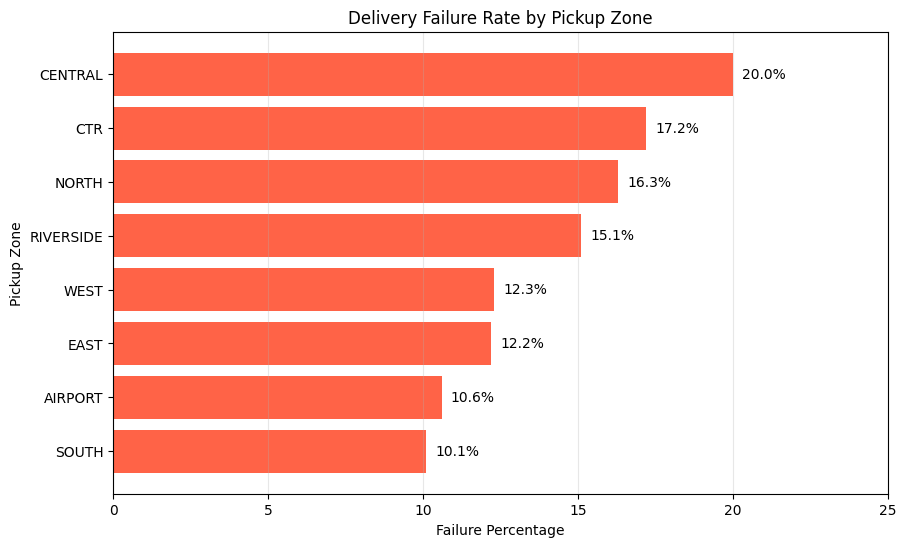

In [8]:
# Fix text columns first
merged["delivery_status"] = merged["delivery_status"].astype(str).str.strip()
merged["pickup_zone"] = merged["pickup_zone"].astype(str).str.strip().str.upper()

# Make zone analysis again
zone_analysis = merged.groupby("pickup_zone").agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("delivery_status", lambda x: (x == "Failed").sum()),
    delayed_deliveries=("delivery_status", lambda x: (x == "Delayed").sum())
).reset_index()

# Calculate failure percentage
zone_analysis["failure_percentage"] = (
    zone_analysis["failed_deliveries"] / zone_analysis["total_deliveries"] * 100
).round(1)

# Sort by highest failure percentage
top_zones = zone_analysis.sort_values("failure_percentage", ascending=False).head(10)

print("Top zones by failure percentage")
print(top_zones)

# Chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_zones["pickup_zone"],
    top_zones["failure_percentage"],
    color="tomato"
)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3,
             bar.get_y() + bar.get_height() / 2,
             str(width) + "%",
             va="center")

plt.xlabel("Failure Percentage")
plt.ylabel("Pickup Zone")
plt.title("Delivery Failure Rate by Pickup Zone")

plt.gca().invert_yaxis()
plt.xlim(0, top_zones["failure_percentage"].max() + 5)
plt.grid(axis="x", alpha=0.3)

plt.show()



Service type value and cost
  service_type  total_order_value  total_delivery_cost    profit
1      Medical            9344.88              1379.48   7965.40
0     Business           12279.23              1655.91  10623.32
4       Retail           19444.86              2906.27  16538.59
2       Parcel           20735.44              3009.01  17726.43
3    Passenger           25463.36              3248.56  22214.80


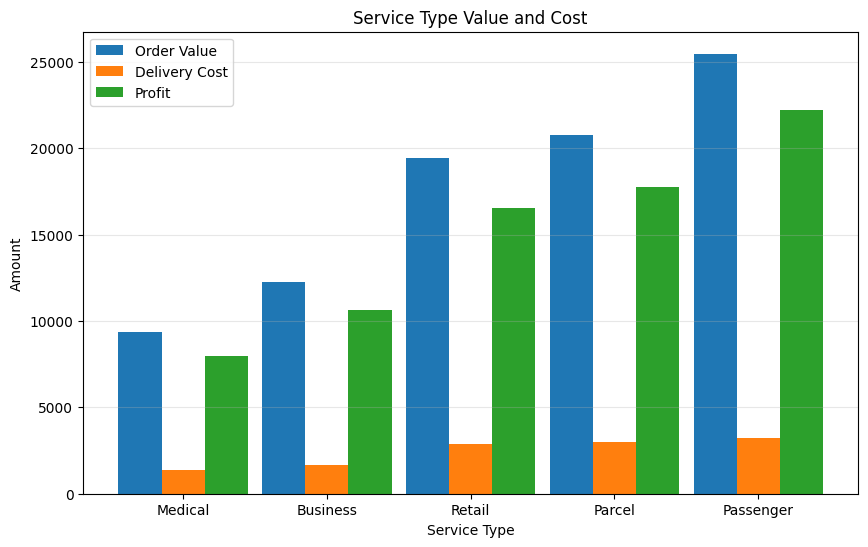

In [9]:
# Chart 2: Service type value and cost

print("Service type value and cost")
print(service_analysis[["service_type", "total_order_value", "total_delivery_cost", "profit"]])

x = np.arange(len(service_analysis))
width = 0.3

plt.figure(figsize=(10, 6))

plt.bar(x - width, service_analysis["total_order_value"], width, label="Order Value")
plt.bar(x, service_analysis["total_delivery_cost"], width, label="Delivery Cost")
plt.bar(x + width, service_analysis["profit"], width, label="Profit")

plt.xticks(x, service_analysis["service_type"])
plt.xlabel("Service Type")
plt.ylabel("Amount")
plt.title("Service Type Value and Cost")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()


Complaint summary
       complaint_type severity  total_complaints  average_resolution_days
0            AppIssue     High                13                13.923077
1            AppIssue      Low                15                 6.066667
2            AppIssue   Medium                25                 7.360000
3             Billing     High                 4                12.000000
4             Billing      Low                 3                 8.000000
5             Billing   Medium                 9                 5.777778
6              Damage     High                 7                15.428571
7              Damage      Low                 6                 6.833333
8              Damage   Medium                 2                10.500000
9               Delay     High                18                12.444444
10              Delay      Low                27                 6.481481
11              Delay   Medium                56                 5.964286
12    DriverBehaviou

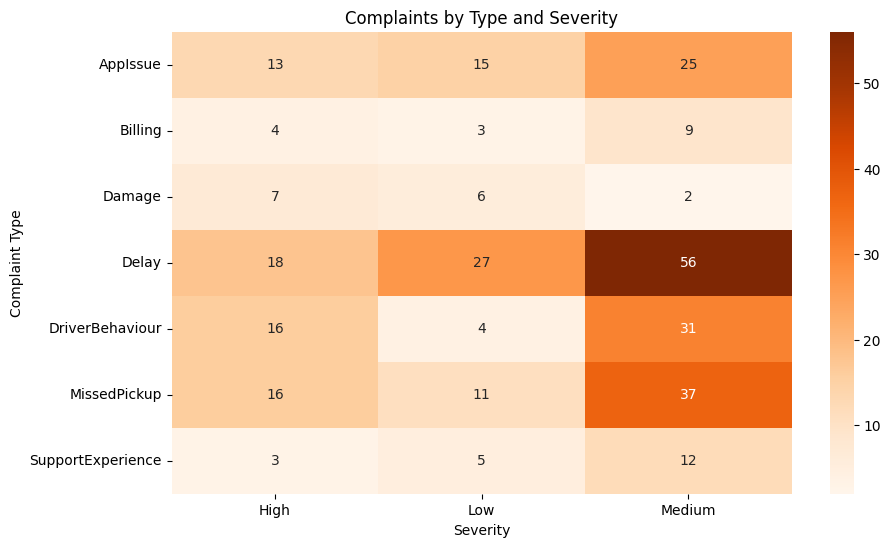


Average resolution days by severity
severity
High      13.116883
Low        6.563380
Medium     6.168605
Name: resolution_days, dtype: float64


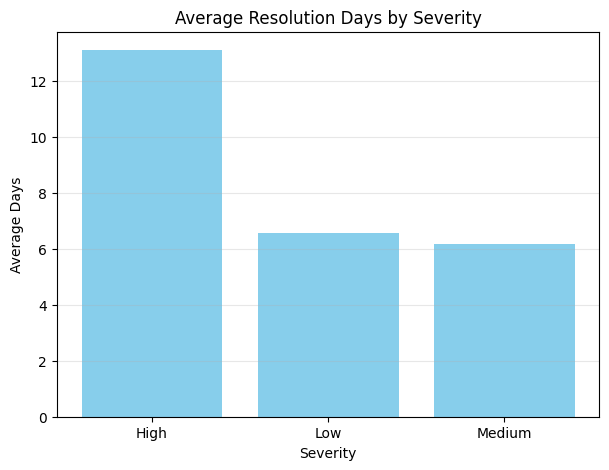

In [10]:
# Chart 3: Complaint analysis

complaint_summary = complaints.groupby(["complaint_type", "severity"]).agg(
    total_complaints=("complaint_id", "count"),
    average_resolution_days=("resolution_days", "mean")
).reset_index()

print("Complaint summary")
print(complaint_summary)

# Make data for heatmap
heatmap_data = complaint_summary.pivot(
    index="complaint_type",
    columns="severity",
    values="total_complaints"
).fillna(0)

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Oranges"
)

plt.title("Complaints by Type and Severity")
plt.xlabel("Severity")
plt.ylabel("Complaint Type")

plt.show()

# Average resolution days by severity

resolution_data = complaints.groupby("severity")["resolution_days"].mean()

print("\nAverage resolution days by severity")
print(resolution_data)

plt.figure(figsize=(7, 5))

plt.bar(
    resolution_data.index,
    resolution_data.values,
    color="skyblue"
)

plt.title("Average Resolution Days by Severity")
plt.xlabel("Severity")
plt.ylabel("Average Days")

plt.grid(axis="y", alpha=0.3)

plt.show()


Route changes and rating data
   manual_route_override_count  customer_rating_post_delivery delivery_status
0                            2                           4.29          OnTime
1                            2                           3.70         Delayed
2                            1                           5.00          OnTime
3                            1                           4.38          OnTime
4                            1                           3.93         Delayed


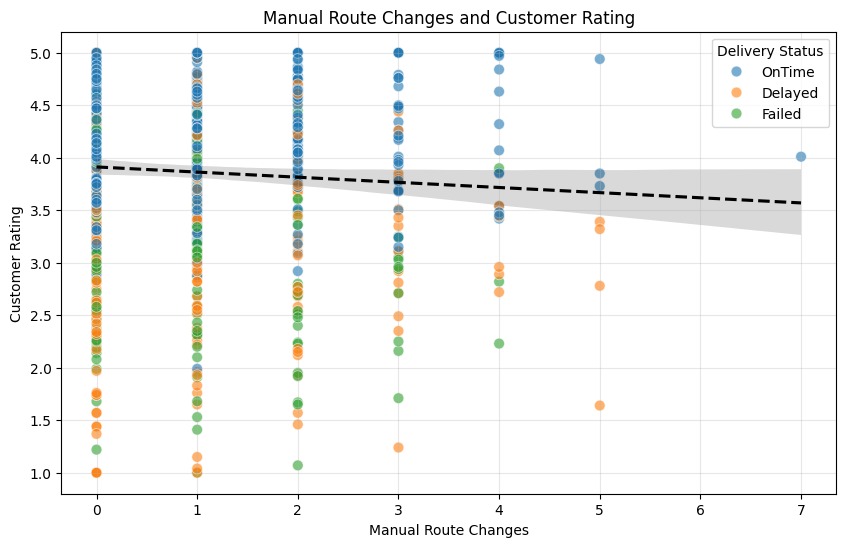

In [11]:
# Chart 4: Route changes and customer rating

plot_data = merged.dropna(subset=["customer_rating_post_delivery"])

print("Route changes and rating data")
print(plot_data[[
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "delivery_status"
]].head())

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_data,
    x="manual_route_override_count",
    y="customer_rating_post_delivery",
    hue="delivery_status",
    alpha=0.6,
    s=60
)

sns.regplot(
    data=plot_data,
    x="manual_route_override_count",
    y="customer_rating_post_delivery",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"}
)

plt.title("Manual Route Changes and Customer Rating")
plt.xlabel("Manual Route Changes")
plt.ylabel("Customer Rating")
plt.legend(title="Delivery Status")
plt.grid(alpha=0.3)

plt.show()


Vehicle count by zone and maintenance status
  assigned_zone maintenance_status  count
0       AIRPORT             Active      6
1       AIRPORT           InRepair      6
2       AIRPORT          Scheduled      1
3       Airport           InRepair      1
4       CENTRAL             Active      7


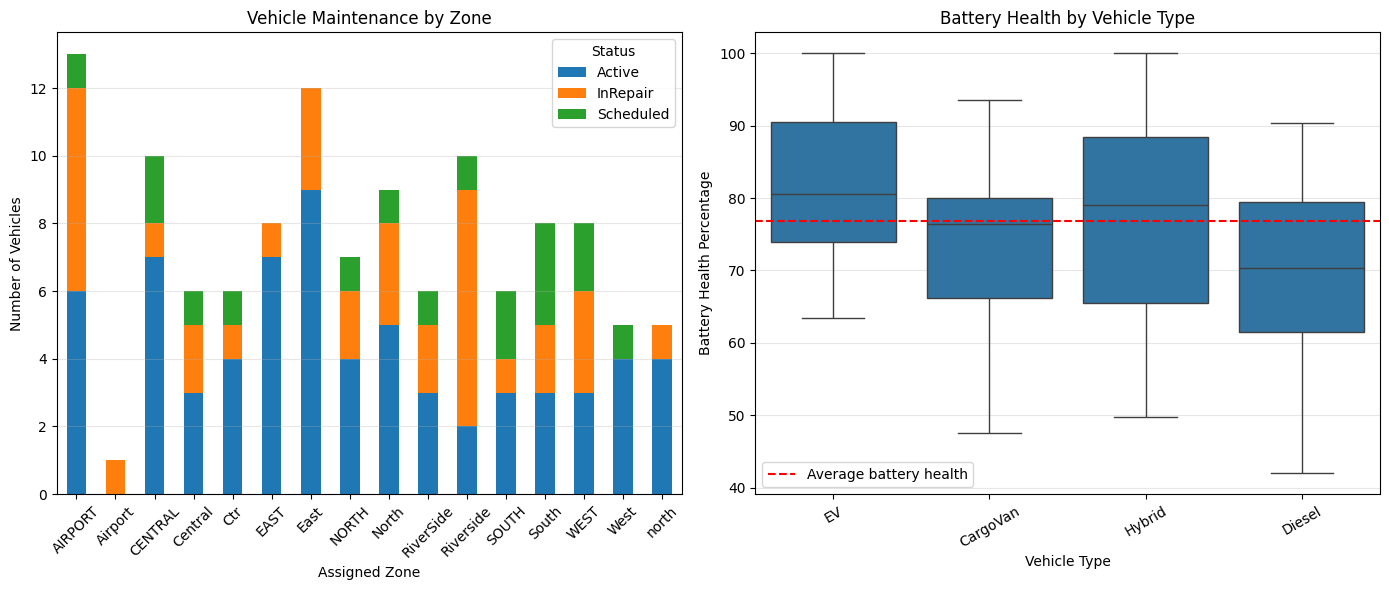

In [12]:
# Chart 5: Vehicle maintenance and battery health

# Count vehicles by zone and maintenance status
fleet_zone = vehicles.groupby(["assigned_zone", "maintenance_status"]).size().reset_index(name="count")

print("Vehicle count by zone and maintenance status")
print(fleet_zone.head())

# Make pivot table for stacked bar chart
fleet_pivot = fleet_zone.pivot_table(
    index="assigned_zone",
    columns="maintenance_status",
    values="count",
    fill_value=0
)

# Create two charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: maintenance status by zone
fleet_pivot.plot(
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("Vehicle Maintenance by Zone")
axes[0].set_xlabel("Assigned Zone")
axes[0].set_ylabel("Number of Vehicles")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Status")
axes[0].grid(axis="y", alpha=0.3)

# Chart 2: battery health by vehicle type
sns.boxplot(
    data=vehicles,
    x="vehicle_type",
    y="battery_health_pct",
    ax=axes[1]
)

axes[1].set_title("Battery Health by Vehicle Type")
axes[1].set_xlabel("Vehicle Type")
axes[1].set_ylabel("Battery Health Percentage")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

# Add average battery health line
average_battery = vehicles["battery_health_pct"].mean()
axes[1].axhline(
    average_battery,
    color="red",
    linestyle="--",
    label="Average battery health"
)
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
# Final summary for Section 3

print("Section 3 summary")
print("-----------------")

print("Total orders:", len(orders))
print("Total deliveries:", len(deliveries))
print("Rows after merging orders and deliveries:", len(merged))

# Delivery status percentages
success_rate = (deliveries["delivery_status"] == "OnTime").mean() * 100
failure_rate = (deliveries["delivery_status"] == "Failed").mean() * 100
delay_rate = (deliveries["delivery_status"] == "Delayed").mean() * 100

print("\nDelivery results")
print("On time percentage:", round(success_rate, 1), "%")
print("Failed percentage:", round(failure_rate, 1), "%")
print("Delayed percentage:", round(delay_rate, 1), "%")

# Simple financial summary
total_value = merged["order_value"].sum()
total_cost = merged["fuel_or_charge_cost"].sum()
profit = total_value - total_cost

print("\nFinancial summary")
print("Total order value:", round(total_value, 2))
print("Total delivery cost:", round(total_cost, 2))
print("Profit:", round(profit, 2))

# Customer rating summary
print("\nCustomer ratings")
print("Average rating:", round(merged["customer_rating_post_delivery"].mean(), 2))
print("Average rating for on time deliveries:",
      round(merged[merged["delivery_status"] == "OnTime"]["customer_rating_post_delivery"].mean(), 2))
print("Average rating for failed deliveries:",
      round(merged[merged["delivery_status"] == "Failed"]["customer_rating_post_delivery"].mean(), 2))

# Correlation from earlier NumPy section
print("\nCorrelation between route changes and fuel cost:")
print(round(correlation, 4))


Section 3 summary
-----------------
Total orders: 1250
Total deliveries: 950
Rows after merging orders and deliveries: 950

Delivery results
On time percentage: 64.8 %
Failed percentage: 13.9 %
Delayed percentage: 21.3 %

Financial summary
Total order value: 87267.77
Total delivery cost: 12199.23
Profit: 75068.54

Customer ratings
Average rating: 3.86
Average rating for on time deliveries: 4.28
Average rating for failed deliveries: 3.05

Correlation between route changes and fuel cost:
0.0987
